In [24]:
from prompt import BASE_SYSTEM_PROMPT
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
import sqlite3
import os
from langchain_core.tools import tool
from dotenv import load_dotenv
load_dotenv()


True

In [25]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import BaseMessage
from typing import TypedDict, Annotated, Literal
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field

In [26]:
class Info(BaseModel):
    name : Annotated[str, Field(description='Name of the respondent')]
    email : Annotated[str, Field(description='Email of the respondent')]
    platform : Annotated[str, Field(description='platform of the respondent')]

In [27]:
class AgentState(TypedDict):
    lead : dict
    intent : Literal["greeting","inquiry","high_intent"]
    rag_context : str
    messages : Annotated[list[BaseMessage], add_messages]

In [28]:
from langgraph.checkpoint.sqlite import SqliteSaver

In [29]:
DBNAME = 'chatbot.db'
conn = sqlite3.connect(
    database=DBNAME,
    check_same_thread=False
)
checkpointer = SqliteSaver(conn=conn)


In [30]:
@tool
def mock_capture_lead(name: str, email: str, platform: str)-> dict:
    """
    WHEN ALL THREE FIELDS- 
    NAME
    EMAIL
    PLATFORM 
    IS COLLECTED THEN ONLY CALL THIS TOOL.
    """

    print(f"Lead captured successfully: {name}, {email}, {platform}")

    return {
    "status": "success",
    }

tools = [mock_capture_lead]


In [31]:
def _get_llm(bind_tools: bool = False):
    api_key = os.getenv("GOOGLE_API_KEY")
    #api_key = os.getenv("GROQ_API_KEY")
    if not api_key:
        raise EnvironmentError("GROQ_API_KEY is not set.")
    #llm = ChatGroq(model='openai/gpt-oss-20b')
    llm=ChatGoogleGenerativeAI(model='models/gemini-2.5-flash')
    if bind_tools:
        return llm.bind_tools(tools)
    return llm

In [32]:
from langchain.messages import SystemMessage, HumanMessage, AIMessage

In [33]:
class RouterDecision(BaseModel):
    intent : Literal['greeting','high_intent','inquiry']

In [34]:
def classify_intent(state: AgentState) -> AgentState:
    """
    Lightweight classifier that reads the last human message
    and sets state["intent"].
    """
    human_texts = [
        m.content for m in state["messages"][-6:] if isinstance(m, HumanMessage)
    ]
    llm = _get_llm(bind_tools=False)
    classification_prompt = [
        SystemMessage(content=(
            "Classify the user current intent using history of messages into exactly one of these labels:\n"
            "  greeting — small talk, hi, hello, how are you, other casual talkings\n"
            "  inquiry — questions about features, pricing, plans, policies, comparisons\n"
            "  high_intent — user wants to sign up, try, buy, or get started with or USER GIVING ITS INFO FOR PURCHASING PLAN OR SHOWING INTEREST IN PRODUCT.\n\n"
            "Respond with ONLY the label. Nothing else."
        )),
        HumanMessage(content="\n".join(human_texts)),
    ]

    llm_structured_output = llm.with_structured_output(RouterDecision)

    response = llm_structured_output.invoke(classification_prompt)
    raw = response.intent.strip().lower()

    if "high_intent" in raw:
        intent = "high_intent"
    elif "inquiry" in raw:
        intent = "inquiry"
    else:
        intent = "greeting"

    print(f"[Agent] Detected intent: {intent}")
    return {**state, "intent": intent}


In [35]:
def route_intent(state: AgentState) -> Literal["rag_node", "lead_node", "chat_node"]:
    intent = state.get("intent", "greeting")
    if intent == "inquiry":
        return "rag_node"
    elif intent == "high_intent":
        return "lead_node"
    else:
        return "chat_node"

In [36]:
def lead_node(state: AgentState) -> AgentState:
    """
    The customer is showing interest in our service.
    Hence collect his/her info such as name, email and platform.
    """
    lead = state.get("lead", {"name": None, "email": None, "platform": None})

    lead_status = (
        "Lead status:\n"
        f"- Name: {lead.get('name') or 'missing'}\n"
        f"- Email: {lead.get('email') or 'missing'}\n"
        f"- Platform: {lead.get('platform') or 'missing'}\n"
    )

    system = SystemMessage(content=(
        f"{lead_status}\n"
        "You are collecting user information.\n"
        "DO NOT call any tools.\n"
        "Only ask for missing fields.\n"
    ))  

    llm = _get_llm(bind_tools=False)
        
    messages_to_send = [system] + [
        m for m in state["messages"] if not isinstance(m, SystemMessage)
    ]
    response = llm.invoke(messages_to_send)

    # Parse any newly provided values from the conversation
    updated_lead = _extract_lead_from_history(state["messages"], lead)
    
    return {
        **state,
        "messages": [response],
        "lead": updated_lead,
    }

In [37]:
import json

In [38]:
def _extract_lead_from_history(messages: list, current_lead: dict) -> dict:
    """
    Simple heuristic updater: asks Gemini to extract name/email/platform
    from the last few human messages.
    """
    # Gather last 6 human messages
    human_texts = [
        m.content for m in messages[-6:] if isinstance(m, HumanMessage)
    ]
    if not human_texts:
        return current_lead

    llm = _get_llm(bind_tools=False)
    extract_prompt = [
        SystemMessage(content=(
            "From the conversation snippets below, extract the user's:\n"
            "  - name (full name if provided)\n"
            "  - email (valid email address)\n"
            "  - platform (YouTube, Instagram, TikTok, etc.)\n\n"
            "Return a JSON object with keys: name, email, platform.\n"
            "Use null for any value not yet provided.\n"
            "Respond ONLY with valid JSON. No explanation."
        )),
        HumanMessage(content="\n".join(human_texts)),
    ]

    try:
        resp = llm.invoke(extract_prompt)
        raw = resp.content.strip().removeprefix("```json").removesuffix("```").strip()
        extracted = json.loads(raw)
        merged = {
            "name":     extracted.get("name")     or current_lead.get("name"),
            "email":    extracted.get("email")    or current_lead.get("email"),
            "platform": extracted.get("platform") or current_lead.get("platform"),
        }
        return merged
    except Exception:
        return current_lead

In [39]:
def chat_node(state: AgentState) -> AgentState:
    """Handles casual greetings and general conversation."""
    system = SystemMessage(content=(
        f"{BASE_SYSTEM_PROMPT}\n\n"
        "The user is just chatting. Be warm and friendly. "
        "Naturally mention you can help with AutoStream plans if relevant."
    ))

    llm = _get_llm(bind_tools=False)
    messages_to_send = [system] + [
        m for m in state["messages"] if not isinstance(m, SystemMessage)
    ]
    response = llm.invoke(messages_to_send)

    return {**state, "messages": [response]}


In [40]:
from rag_pipeline import retriever, format_docs
from prompt import BASE_SYSTEM_PROMPT

In [41]:
def rag_node(state: AgentState) -> AgentState:
    """Retrieve context from ChromaDB, then answer with Gemini."""
    last_human = next(
        (m.content for m in reversed(state["messages"]) if isinstance(m, HumanMessage)),
        ""
    )

    # Retrieve from vector store
    try:
        docs = retriever.invoke(last_human)
        context = format_docs(docs)
    except Exception as e:
        context = ""

    print(f"[RAG] Retrieved {len(context)} chars of context.")

    system = SystemMessage(content=(
        f"{BASE_SYSTEM_PROMPT}\n\n"
        f"[RETRIEVED CONTEXT]\n{context}\n[END CONTEXT]"
    ))

    llm = _get_llm(bind_tools=False)
    messages_to_send = [system] + [
        m for m in state["messages"] if not isinstance(m, SystemMessage)
    ]
    response = llm.invoke(messages_to_send)

    return {
        **state,
        "messages": [response],
        "rag_context": context,
    }


In [42]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import AIMessage
from typing import Literal

# ---------------------------
# TOOL NODE
# ---------------------------
tool_node = ToolNode(tools)

# ---------------------------
# PREPARE TOOL CALL NODE
# ---------------------------
def tool_call(state: AgentState) -> AgentState:
    lead = state["lead"]

    result = mock_capture_lead.invoke({
        "name": lead["name"],
        "email": lead["email"],
        "platform": lead["platform"],
    })

    return {
        **state,
        "messages": state["messages"] + [
            AIMessage(content="You're all set. We will contact you soon.")
        ],
        "lead": result
    }
# ---------------------------
# TOOL ROUTER
# ---------------------------
def tool_router(state: AgentState) -> Literal["tool_call", "lead_node"]:
    lead = state.get("lead", {})

    is_complete = all([
        lead.get("name"),
        lead.get("email"),
        lead.get("platform")
    ])

    if is_complete:
        print("[Router] Lead complete → calling tool")
        return "tool_call"
    else:
        print("[Router] Lead incomplete → continue collecting")
        return "lead_node"

# ---------------------------
# BUILD GRAPH
# ---------------------------
graph = StateGraph(AgentState)

# Nodes
graph.add_node("classify_intent", classify_intent)
graph.add_node("rag_node", rag_node)
graph.add_node("lead_node", lead_node)
graph.add_node("chat_node", chat_node)
graph.add_node("tool_call", tool_call)

# Start
graph.add_edge(START, "classify_intent")

# Intent routing
graph.add_conditional_edges(
    "classify_intent",
    route_intent,
    {
        "rag_node": "rag_node",
        "lead_node": "lead_node",
        "chat_node": "chat_node",
    }
)

# Normal exits
graph.add_edge("rag_node", END)
graph.add_edge("chat_node", END)

# Lead flow → tool router
graph.add_conditional_edges(
    "lead_node",
    tool_router,
    {
        "tool_call": "tool_call",
        "lead_node": END,
    }
)

# Tool execution chain
graph.add_edge("tool_call", END)

# Compile
chatbot = graph.compile(checkpointer=checkpointer)

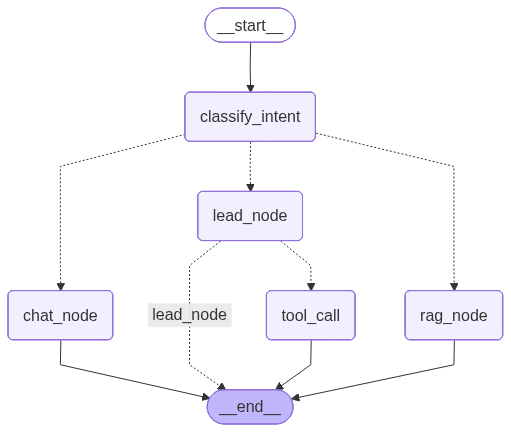

In [43]:
chatbot

In [44]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

In [ ]:
import uuid

thread_id = "707552ba-d9bb-4706-8937-00ef46c0c42e"


while True:
    user_query = input('Ask to AI')
    if user_query.strip().lower() in ['exit', 'bye', 'quit']:
        break
    config = {'configurable': {'thread_id': thread_id}}
    response = chatbot.invoke({'messages': [HumanMessage(content=user_query)]}, config=config)

    last_msg = response["messages"][-1]

    print("YOU:", user_query)

    if isinstance(last_msg, AIMessage):
        if last_msg.tool_calls:
            print("AI: [Calling tool...]")
        else:
            print("AI:", last_msg.content)
    else:
        print("AI:", str(last_msg))

[Agent] Detected intent: greeting
YOU: hi
AI: Hi there! I'm Aria, your friendly AutoStream assistant. How can I help you learn about creating AI-powered videos today?
[Agent] Detected intent: inquiry
[RAG] Retrieved 184 chars of context.
YOU: what are your plan-
AI: We offer a Basic Plan for $29/month, which includes 10 videos at 720p resolution.

We also have a Pro Plan for $79/month, offering unlimited videos and 4K resolution.
[Agent] Detected intent: high_intent
[Router] Lead incomplete → continue collecting
YOU: I am interested in purchasing pro plan
AI: Great! To help you get started with the Pro Plan, could you please tell me your name?
[Agent] Detected intent: high_intent
[Router] Lead incomplete → continue collecting
YOU: Rajat
AI: Thanks, Rajat!

And what's your email address?
[Agent] Detected intent: high_intent
[Router] Lead incomplete → continue collecting
YOU: rajattsharma@gmail.com
AI: Thanks, Rajat!

Could you also let me know which platform you'll be using AutoStream o

ChatGoogleGenerativeAIError: Error calling model 'models/gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 12.345750942s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerMode

: 

: 

: 